Preorden: ['1', '2', '7', '3', '4', '6', '5', '8', '9']
Aristas de árbol: [('1', '2'), ('1', '7'), ('7', '3'), ('3', '4'), ('7', '6'), ('5', '8'), ('5', '9')]
Aristas de retroceso: []
Componentes (bosque): [{'7', '2', '4', '3', '1', '6'}, {'9', '8', '5'}]


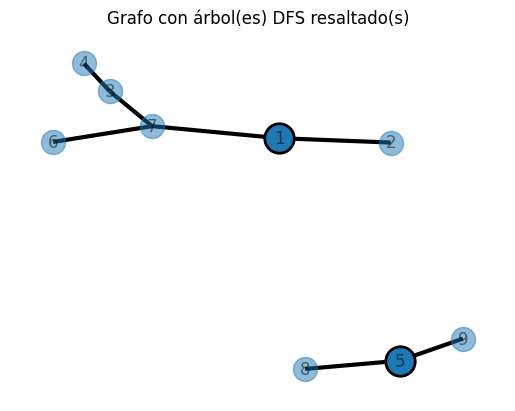

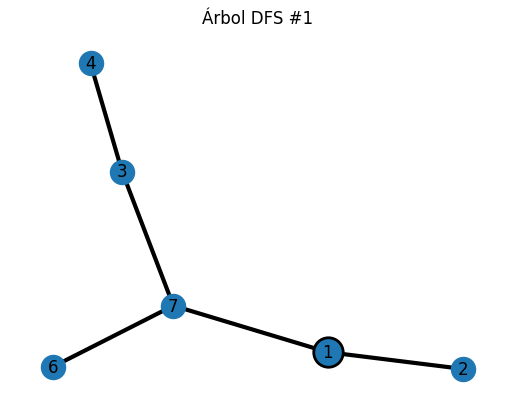

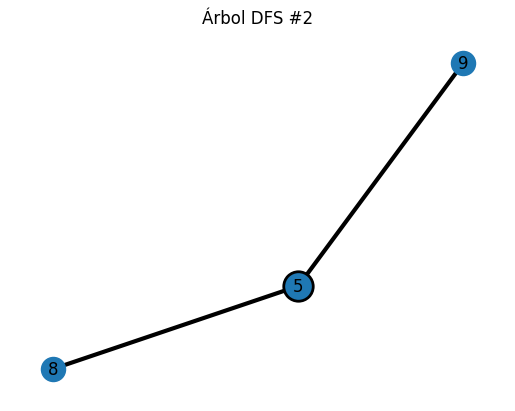

In [4]:
from typing import Dict, Set, List, Tuple, Optional, Hashable, Iterable
from dataclasses import dataclass
import matplotlib.pyplot as plt
import networkx as nx


# --------------------------
# 1) Aux: construir grafo NX
# --------------------------
def build_nx_graph(edges: Iterable[Tuple[Hashable, Hashable]], directed: bool = False) -> nx.Graph:
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_edges_from(edges)
    return G


# --------------------------
# 2) Resultado del DFS
# --------------------------
@dataclass
class DFSForestNX:
    preorder: List[Hashable]
    parent: Dict[Hashable, Optional[Hashable]]
    discovery: Dict[Hashable, int]
    finish: Dict[Hashable, int]
    tree_edges: List[Tuple[Hashable, Hashable]]
    back_edges: List[Tuple[Hashable, Hashable]]
    components: List[Set[Hashable]]


# --------------------------
# 3) DFS iterativo usando G de NetworkX
# --------------------------
def dfs_forest_nx(G: nx.Graph, start: Optional[Hashable] = None,
                  order: Optional[Iterable[Hashable]] = None) -> DFSForestNX:
    visited: Set[Hashable] = set()
    parent: Dict[Hashable, Optional[Hashable]] = {}
    disc: Dict[Hashable, int] = {}
    fin: Dict[Hashable, int] = {}
    preorder: List[Hashable] = []
    tree_edges: List[Tuple[Hashable, Hashable]] = []
    back_edges: List[Tuple[Hashable, Hashable]] = []
    components: List[Set[Hashable]] = []
    t = 0

    all_nodes = list(G.nodes())
    if order is None:
        try:
            all_nodes_sorted = sorted(all_nodes)
        except TypeError:
            all_nodes_sorted = all_nodes
    else:
        all_nodes_sorted = list(order)
        for u in all_nodes:
            if u not in all_nodes_sorted:
                all_nodes_sorted.append(u)

    roots = [start] + [u for u in all_nodes_sorted if u != start] if start is not None else all_nodes_sorted
    finished: Set[Hashable] = set()

    for r in roots:
        if r in visited:
            continue
        parent[r] = None
        comp_nodes: Set[Hashable] = {r}
        neigh_r = list(G.neighbors(r))
        try:
            neigh_r.sort()
        except TypeError:
            pass
        stack: List[Tuple[Hashable, Iterable[Hashable]]] = [(r, iter(neigh_r))]
        visited.add(r)
        disc[r] = t; t += 1
        preorder.append(r)

        while stack:
            u, it = stack[-1]
            try:
                v = next(it)
                if v not in visited:
                    parent[v] = u
                    tree_edges.append((u, v))
                    visited.add(v)
                    comp_nodes.add(v)
                    disc[v] = t; t += 1
                    preorder.append(v)
                    neigh_v = list(G.neighbors(v))
                    try:
                        neigh_v.sort()
                    except TypeError:
                        pass
                    stack.append((v, iter(neigh_v)))
                elif v != parent.get(u) and v not in finished:
                    back_edges.append((u, v))
            except StopIteration:
                fin[u] = t; t += 1
                finished.add(u)
                stack.pop()

        components.append(comp_nodes)

    return DFSForestNX(preorder, parent, disc, fin, tree_edges, back_edges, components)


# --------------------------
# 4) Dibujo con NetworkX
# --------------------------
def draw_nx_graph(G: nx.Graph, pos=None, ax=None, with_labels: bool = True):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)  # layout agradable
    if ax is None:
        fig, ax = plt.subplots()

    if isinstance(G, nx.DiGraph):
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300)
        if with_labels:
            nx.draw_networkx_labels(G, pos, ax=ax)
        nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, width=1, alpha=0.5)
    else:
        nx.draw(G, pos, with_labels=with_labels, node_size=300, width=1, alpha=0.5, ax=ax)

    ax.set_title("Grafo")
    ax.set_axis_off()
    return pos

def draw_nx_dfs_forest(G: nx.Graph, forest: DFSForestNX, pos=None, ax=None):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    if ax is None:
        fig, ax = plt.subplots()

    draw_nx_graph(G, pos=pos, ax=ax, with_labels=True)

    # Resalta aristas del árbol DFS
    if isinstance(G, nx.DiGraph):
        nx.draw_networkx_edges(G, pos, edgelist=forest.tree_edges, width=3, arrows=True, ax=ax)
    else:
        nx.draw_networkx_edges(G, pos, edgelist=forest.tree_edges, width=3, ax=ax)

    # Raíces con borde
    roots = [u for u, p in forest.parent.items() if p is None]
    nx.draw_networkx_nodes(G, pos, nodelist=roots, node_size=450, linewidths=2, edgecolors="black", ax=ax)

    ax.set_title("Grafo con árbol(es) DFS resaltado(s)")
    ax.set_axis_off()
    return pos

def draw_nx_each_tree(G: nx.Graph, forest: DFSForestNX, pos=None):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    for i, comp in enumerate(forest.components, 1):
        fig, ax = plt.subplots()
        sub_nodes = list(comp)

        # Aristas fuera de árbol para contexto
        if isinstance(G, nx.DiGraph):
            tree_edges_set = set(forest.tree_edges)
            off_edges = [(u, v) for u, v in G.edges() if u in comp and v in comp and (u, v) not in tree_edges_set]
            nx.draw_networkx_edges(G, pos, edgelist=off_edges, width=1, alpha=0.3, arrows=True, ax=ax, style='dashed')
        else:
            tree_edges_set = {tuple(sorted((u, v))) for u, v in forest.tree_edges}
            off_edges = [tuple(sorted((u, v))) for u, v in G.edges() if u in comp and v in comp]
            off_edges = [e for e in set(off_edges) if e not in tree_edges_set]
            nx.draw_networkx_edges(G, pos, edgelist=off_edges, width=1, alpha=0.3, ax=ax, style='dashed')

        # Aristas de árbol en grueso
        tree_edges = [e for e in forest.tree_edges if e[0] in comp and e[1] in comp]
        if isinstance(G, nx.DiGraph):
            nx.draw_networkx_edges(G, pos, edgelist=tree_edges, width=3, arrows=True, ax=ax)
        else:
            nx.draw_networkx_edges(G, pos, edgelist=tree_edges, width=3, ax=ax)

        # Nodos, etiquetas y raíces
        nx.draw_networkx_nodes(G, pos, nodelist=sub_nodes, node_size=300, ax=ax)
        nx.draw_networkx_labels(G, pos, labels={u: str(u) for u in sub_nodes}, ax=ax)
        roots = [u for u in sub_nodes if forest.parent.get(u) is None]
        nx.draw_networkx_nodes(G, pos, nodelist=roots, node_size=450, linewidths=2, edgecolors="black", ax=ax)

        ax.set_title(f"Árbol DFS #{i}")
        ax.set_axis_off()

    return pos


# --------------------------
# 5) Ejemplo de uso
# --------------------------
if __name__ == "__main__":
    edges = [
        ('1','2'), ('1','7'), ('7','3'), ('3','4'), ('7','6'),
        ('5','8'), ('5','9')
    ]
    G = build_nx_graph(edges, directed=False)
    result = dfs_forest_nx(G, start='1')
    print("Preorden:", result.preorder)
    print("Aristas de árbol:", result.tree_edges)
    print("Aristas de retroceso:", result.back_edges)
    print("Componentes (bosque):", result.components)

    pos = draw_nx_dfs_forest(G, result)   # grafo + árbol(es) DFS
    draw_nx_each_tree(G, result, pos=pos) # una figura por árbol
    plt.show()


Preorden: ['A', 'B', 'D', 'C', 'E', 'F', 'G']
Aristas de árbol: [('A', 'B'), ('B', 'D'), ('D', 'C'), ('C', 'E'), ('F', 'G')]
Aristas de retroceso: [('C', 'A')]
Componentes (bosque): [{'E', 'C', 'A', 'B', 'D'}, {'G', 'F'}]


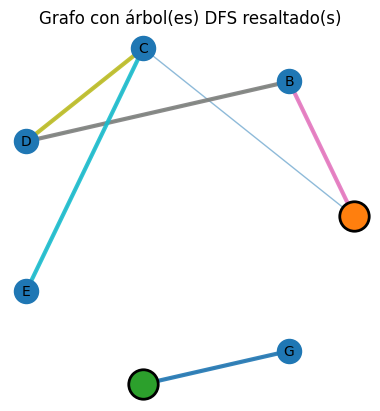

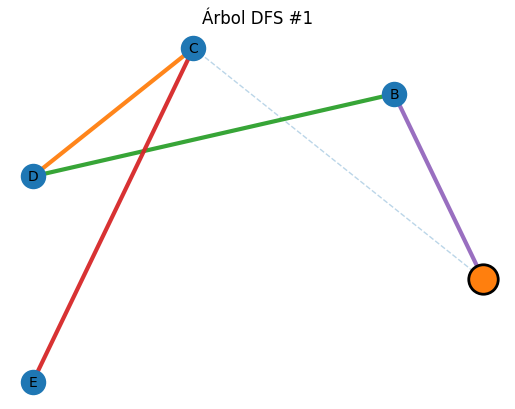

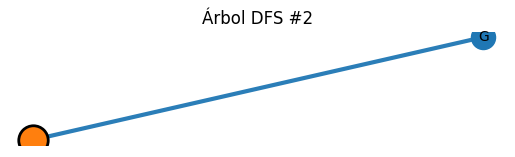

In [8]:
from typing import Dict, Set, List, Tuple, Optional, Hashable, Iterable
from dataclasses import dataclass
import math
import matplotlib.pyplot as plt


# --------------------------
# 1) Modelo de Grafo simple
# --------------------------
class Graph:
    def __init__(self, directed: bool = False):
        self.directed = directed
        self.adj: Dict[Hashable, Set[Hashable]] = {}

    def add_node(self, u: Hashable) -> None:
        if u not in self.adj:
            self.adj[u] = set()

    def add_edge(self, u: Hashable, v: Hashable) -> None:
        self.add_node(u)
        self.add_node(v)
        self.adj[u].add(v)
        if not self.directed:
            self.adj[v].add(u)

    def add_edges_from(self, edges: Iterable[Tuple[Hashable, Hashable]]) -> None:
        for u, v in edges:
            self.add_edge(u, v)

    def nodes(self) -> List[Hashable]:
        return list(self.adj.keys())

    def neighbors(self, u: Hashable) -> Set[Hashable]:
        return set(self.adj.get(u, set()))

    def __repr__(self) -> str:
        m = sum(len(n) for n in self.adj.values())
        return f"Graph(directed={self.directed}, |V|={len(self.adj)}, |E|={m})"


# --------------------------
# 2) Resultado del DFS
# --------------------------
@dataclass
class DFSForest:
    preorder: List[Hashable]
    parent: Dict[Hashable, Optional[Hashable]]
    discovery: Dict[Hashable, int]
    finish: Dict[Hashable, int]
    tree_edges: List[Tuple[Hashable, Hashable]]
    back_edges: List[Tuple[Hashable, Hashable]]
    components: List[Set[Hashable]]   # conjunto de nodos por cada árbol del bosque


# --------------------------
# 3) Algoritmo DFS (iterativo)
# --------------------------
def dfs(graph: Graph, start: Optional[Hashable] = None,
        order: Optional[Iterable[Hashable]] = None) -> DFSForest:
    """
    DFS sobre todo el grafo (devuelve bosque).
    - start: nodo inicial preferente (opcional).
    - order: orden global de raíces si hay varias componentes (opcional).
    """
    visited: Set[Hashable] = set()
    parent: Dict[Hashable, Optional[Hashable]] = {}
    disc: Dict[Hashable, int] = {}
    fin: Dict[Hashable, int] = {}
    preorder: List[Hashable] = []
    tree_edges: List[Tuple[Hashable, Hashable]] = []
    back_edges: List[Tuple[Hashable, Hashable]] = []
    components: List[Set[Hashable]] = []
    t = 0

    # Orden de raíces (para componentes desconectadas)
    all_nodes = graph.nodes()
    if order is None:
        try:
            all_nodes_sorted = sorted(all_nodes)
        except TypeError:
            all_nodes_sorted = all_nodes  # si tipos mixtos no ordenables
    else:
        all_nodes_sorted = list(order)
        for u in all_nodes:
            if u not in all_nodes_sorted:
                all_nodes_sorted.append(u)

    roots = [start] + [u for u in all_nodes_sorted if u != start] if start is not None else all_nodes_sorted
    finished: Set[Hashable] = set()

    for r in roots:
        if r in visited:
            continue
        comp_nodes: Set[Hashable] = set()
        parent[r] = None
        # pila con iteradores de vecinos para DFS iterativo
        neigh = list(graph.neighbors(r))
        try:
            neigh.sort()
        except TypeError:
            pass
        stack: List[Tuple[Hashable, Iterable[Hashable]]] = [(r, iter(neigh))]
        visited.add(r)
        comp_nodes.add(r)
        disc[r] = t; t += 1
        preorder.append(r)

        while stack:
            u, it = stack[-1]
            try:
                v = next(it)
                if v not in visited:
                    parent[v] = u
                    tree_edges.append((u, v))
                    visited.add(v)
                    comp_nodes.add(v)
                    disc[v] = t; t += 1
                    preorder.append(v)
                    neigh_v = list(graph.neighbors(v))
                    try:
                        neigh_v.sort()
                    except TypeError:
                        pass
                    stack.append((v, iter(neigh_v)))
                elif v != parent.get(u) and v not in finished:
                    # Arista de retroceso (en no dirigidos: no cuenta la arista al padre)
                    back_edges.append((u, v))
            except StopIteration:
                fin[u] = t; t += 1
                finished.add(u)
                stack.pop()

        components.append(comp_nodes)

    return DFSForest(preorder, parent, disc, fin, tree_edges, back_edges, components)


# --------------------------
# 4) Layout y dibujo (Matplotlib puro)
# --------------------------
def circular_layout(nodes: Iterable[Hashable], scale: float = 1.0) -> Dict[Hashable, Tuple[float, float]]:
    nodes = list(nodes)
    n = len(nodes)
    pos: Dict[Hashable, Tuple[float, float]] = {}
    for i, u in enumerate(sorted(nodes, key=lambda x: str(x))):
        angle = 2 * math.pi * i / n if n else 0
        pos[u] = (scale * math.cos(angle), scale * math.sin(angle))
    return pos

def draw_graph(graph: Graph, pos=None, ax=None, with_labels: bool = True):
    if ax is None:
        fig, ax = plt.subplots()
    if pos is None:
        pos = circular_layout(graph.nodes())

    drawn = set()
    for u in graph.nodes():
        for v in graph.neighbors(u):
            if not graph.directed:
                key = tuple(sorted((u, v), key=lambda x: str(x)))
                if key in drawn:
                    continue
                drawn.add(key)
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], linewidth=1, alpha=0.5)
            else:
                ax.annotate("", xy=pos[v], xytext=pos[u],
                            arrowprops=dict(arrowstyle="->", lw=1, alpha=0.5))

    xs = [pos[u][0] for u in graph.nodes()]
    ys = [pos[u][1] for u in graph.nodes()]
    ax.scatter(xs, ys, s=300, zorder=3)
    if with_labels:
        for u in graph.nodes():
            ax.text(pos[u][0], pos[u][1], str(u), ha='center', va='center', fontsize=10, zorder=4)
    ax.set_aspect('equal')
    ax.axis('off')
    return pos

def draw_dfs_forest(graph: Graph, forest: DFSForest, pos=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    if pos is None:
        pos = circular_layout(graph.nodes())

    draw_graph(graph, pos=pos, ax=ax, with_labels=True)

    # Aristas del/los árbol(es) DFS en grueso
    for (u, v) in forest.tree_edges:
        if graph.directed:
            ax.annotate("", xy=pos[v], xytext=pos[u],
                        arrowprops=dict(arrowstyle="->", lw=3, alpha=0.9))
        else:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], linewidth=3, alpha=0.9)

    # Raíces (parent == None) con borde
    for u, p in forest.parent.items():
        if p is None:
            ax.scatter([pos[u][0]], [pos[u][1]], s=450, marker='o',
                       edgecolors='black', linewidths=2, zorder=5)

    ax.set_title("Grafo con árbol(es) DFS resaltado(s)")
    return pos

def draw_each_dfs_tree(graph: Graph, forest: DFSForest, pos=None):
    if pos is None:
        pos = circular_layout(graph.nodes())

    for i, comp in enumerate(forest.components, 1):
        fig, ax = plt.subplots()

        # Aristas dentro de la componente que NO son de árbol (para contexto)
        off_edges = []
        seen = set()
        for u in comp:
            for v in graph.neighbors(u):
                if v not in comp:
                    continue
                if not graph.directed:
                    key = tuple(sorted((u, v), key=lambda x: str(x)))
                    if key in seen:
                        continue
                    seen.add(key)
                off_edges.append((u, v))

        tree_edges = {(u, v) for (u, v) in forest.tree_edges if u in comp and v in comp}
        undirected_tree_set = {tuple(sorted((u, v), key=lambda x: str(x))) for (u, v) in tree_edges}
        off_unique = []
        seen2 = set()
        for (u, v) in off_edges:
            if graph.directed:
                key = (u, v)
                if key in tree_edges:
                    continue
            else:
                key = tuple(sorted((u, v), key=lambda x: str(x)))
                if key in undirected_tree_set:
                    continue
            if key in seen2:
                continue
            seen2.add(key)
            off_unique.append((u, v))

        # Dibujo: aristas fuera de árbol (tenues)
        for (u, v) in off_unique:
            if graph.directed:
                ax.annotate("", xy=pos[v], xytext=pos[u],
                            arrowprops=dict(arrowstyle="->", lw=1, alpha=0.3))
            else:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        linewidth=1, alpha=0.3, linestyle='--')

        # Dibujo: aristas de árbol (gruesas)
        for (u, v) in tree_edges:
            if graph.directed:
                ax.annotate("", xy=pos[v], xytext=pos[u],
                            arrowprops=dict(arrowstyle="->", lw=3, alpha=0.95))
            else:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], linewidth=3, alpha=0.95)

        # Nodos y etiquetas
        xs = [pos[u][0] for u in comp]
        ys = [pos[u][1] for u in comp]
        ax.scatter(xs, ys, s=300, zorder=3)
        for u in comp:
            ax.text(pos[u][0], pos[u][1], str(u), ha='center', va='center', fontsize=10, zorder=4)

        # Raíces
        roots = [u for u in comp if forest.parent.get(u) is None]
        for r in roots:
            ax.scatter([pos[r][0]], [pos[r][1]], s=450, marker='o',
                       edgecolors='black', linewidths=2, zorder=5)

        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f"Árbol DFS #{i}")

    return pos


# --------------------------
# 5) Ejemplo de uso
# --------------------------
if __name__ == "__main__":
    # Grafo no dirigido con 2 componentes
    g = Graph(directed=False)
    g.add_edges_from([
        ('A','B'), ('A','C'), ('B','D'), ('C','D'), ('C','E'),
        ('F','G')
    ])

    result = dfs(g, start='A')  # puedes omitir start o cambiarlo
    print("Preorden:", result.preorder)
    print("Aristas de árbol:", result.tree_edges)
    print("Aristas de retroceso:", result.back_edges)
    print("Componentes (bosque):", result.components)

    pos = circular_layout(g.nodes())
    draw_dfs_forest(g, result, pos=pos)
    draw_each_dfs_tree(g, result, pos=pos)
    plt.show()
